# Machine Learning

This notebook develops and compares two classification models:

1. Logistic Regression as an interpretable baseline
2. A constrained Random Forest as a more complex model

Recall will be prioritised because a false negative would represent a hazardous NEO being classified as non-hazardous.

In [114]:
# Import the libraries needed for splitting the data, preprocessing, modelling and evaluation.
# Keep all of the main imports together here so the modelling steps below are easier to follow.
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

# Load the engineered dataset created in the previous notebook.
# This already contains the primary NEO data, supplementary orbital data and the match flag.
data = pd.read_csv("combined_neo_dataset.csv")

In [115]:
# Only use records that successfully matched to the supplementary dataset for modelling.
# The orbital variables used below are only available for these matched NEO records, so unmatched rows cannot be used here.
model_data = data[data["matched_supplementary"] == True].copy()

# Check how many rows remain after restricting the data to the matched subset.
model_data.shape

(241900, 17)

In [116]:
# Select the predictor variables identified during the earlier data engineering and exploratory analysis.
# These include physical characteristics, close-approach measures and supplementary orbital features.
features = [
    "absolute_magnitude",
    "estimated_diameter_max",
    "relative_velocity",
    "miss_distance",
    "e",
    "a",
    "q",
    "i",
    "per",
    "class"
]

# X contains the model inputs, while y is the hazardous/non-hazardous target variable.
X = model_data[features]
y = model_data["is_hazardous"]
# Keep the NEO identifier separately so repeated observations of the same asteroid can be grouped during the split.
# This prevents the same asteroid appearing in both training and testing data.
groups = model_data["neo_id"]

In [117]:
# Check the selected modelling features for missing values before splitting and training the models.
# Any remaining nulls would need to be handled before the algorithms could use these columns reliably.
X.isnull().sum()

absolute_magnitude        0
estimated_diameter_max    0
relative_velocity         0
miss_distance             0
e                         0
a                         0
q                         0
i                         0
per                       0
class                     0
dtype: int64

In [118]:
# Use a grouped train/test split rather than a standard random split.
# Because the dataset can contain repeated observations for the same NEO, grouping by neo_id keeps each asteroid entirely in one set.
# An 80/20 split is used and random_state makes the result reproducible.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

# Generate the row indices for the training and testing sets using the NEO identifier as the grouping variable.
train_index, test_index = next(
    splitter.split(X, y, groups=groups)
)

# Apply the split indices to the features and target.
X_train = X.iloc[train_index]
X_test = X.iloc[test_index]

y_train = y.iloc[train_index]
y_test = y.iloc[test_index]

# Keep the corresponding NEO IDs as well to verify that no asteroid appears in both sets.
groups_train = groups.iloc[train_index]
groups_test = groups.iloc[test_index]

In [119]:
# Check the size of each split to confirm that the expected training/testing proportions were created.
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

# Explicitly test for any overlap in asteroid IDs between the two sets.
# A result of zero confirms that the grouped split has prevented data leakage between training and testing.
overlapping_asteroids = set(groups_train).intersection(set(groups_test))

print("Asteroids appearing in both sets:", len(overlapping_asteroids))

Training rows: 194057
Testing rows: 47843
Asteroids appearing in both sets: 0


In [120]:
# Compare the hazardous-class distribution in the training and testing sets.
# This checks that the grouped split has not produced very different class proportions between the two samples.
print("Training hazardous rate:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting hazardous rate:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training hazardous rate:
is_hazardous
False    84.56
True     15.44
Name: proportion, dtype: float64

Testing hazardous rate:
is_hazardous
False    85.05
True     14.95
Name: proportion, dtype: float64


In [121]:
# Convert the categorical orbit class into numeric dummy variables so it can be used by the models.
# drop_first=True removes one reference category and avoids creating a redundant dummy column.
X_train_encoded = pd.get_dummies(
    X_train,
    columns=["class"],
    drop_first=True
)

# Apply the same encoding step to the test data.
X_test_encoded = pd.get_dummies(
    X_test,
    columns=["class"],
    drop_first=True
)

In [122]:
# Align the test-set dummy columns with the training set.
# A class may appear in one split but not the other, so reindexing guarantees the models receive the same feature columns.
# Any missing dummy column in the test set is filled with 0.
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [123]:
# Check that the encoded training and testing datasets now have the same number of feature columns.
print("Training feature shape:", X_train_encoded.shape)
print("Testing feature shape:", X_test_encoded.shape)

Training feature shape: (194057, 14)
Testing feature shape: (47843, 14)


In [124]:
# Standardise the numeric feature values for Logistic Regression.
# The scaler is fitted only on the training data so information from the test set does not influence preprocessing.
scaler = StandardScaler()

# Fit and transform the training data, then use those same learned scaling parameters on the test data.
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [125]:
# Import Logistic Regression to use as the simpler baseline classification model.
from sklearn.linear_model import LogisticRegression

# Use balanced class weights because hazardous NEO records are the minority class.
# This gives the minority class more influence during training, which supports the aim of reducing missed hazardous objects.
# max_iter is increased to give the model enough iterations to converge.
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train the Logistic Regression model using the scaled training features.
logistic_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [126]:
# Generate class predictions for the unseen test data using the default classification threshold.
logistic_predictions = logistic_model.predict(X_test_scaled)

In [127]:
# Get the predicted probability of the hazardous class as well as the class predictions.
# These probabilities are required for ROC-AUC and later threshold-based evaluation curves.
logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model using several measures rather than accuracy alone.
# Recall is particularly important here because a false negative represents a hazardous NEO being classified as non-hazardous.
print("Accuracy:", round(accuracy_score(y_test, logistic_predictions), 3))
print("Precision:", round(precision_score(y_test, logistic_predictions), 3))
print("Recall:", round(recall_score(y_test, logistic_predictions), 3))
print("F1-score:", round(f1_score(y_test, logistic_predictions), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, logistic_probabilities), 3))

# Display the confusion matrix so the numbers of true/false positives and negatives can also be inspected directly.
print("\nConfusion matrix:")
print(confusion_matrix(y_test, logistic_predictions))

Accuracy: 0.786
Precision: 0.402
Recall: 0.882
F1-score: 0.552
ROC-AUC: 0.878

Confusion matrix:
[[31301  9389]
 [  844  6309]]


### Logistic Regression results

Logistic Regression achieved a recall of 0.882, correctly identifying most hazardous records in the test set. However, precision was lower at 0.402, meaning the model produced a relatively high number of false positives.

This reflects the use of balanced class weights and the decision to prioritise recall. In the planetary-defence context, a false negative is potentially more serious than a false positive because it represents a hazardous NEO being missed.

In [128]:
# Train an initial Random Forest so its performance can be compared with the Logistic Regression baseline.
# Balanced class weights are again used because the target classes are imbalanced.
# n_jobs=-1 allows the model to use all available processor cores while fitting the trees.
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Random Forest does not require the standardised version of the features, so the encoded training data is used directly.
random_forest_model.fit(X_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [129]:
# Generate the Random Forest class predictions for the test data.
random_forest_predictions = random_forest_model.predict(X_test_encoded)

# Also keep the hazardous-class probabilities for ROC-AUC and the later comparison curves.
random_forest_probabilities = random_forest_model.predict_proba(
    X_test_encoded
)[:, 1]

In [130]:
# Calculate the same evaluation measures used for Logistic Regression so the two models can be compared consistently.
print(
    "Accuracy:",
    round(accuracy_score(y_test, random_forest_predictions), 3)
)

print(
    "Precision:",
    round(precision_score(y_test, random_forest_predictions), 3)
)

print(
    "Recall:",
    round(recall_score(y_test, random_forest_predictions), 3)
)

print(
    "F1-score:",
    round(f1_score(y_test, random_forest_predictions), 3)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, random_forest_probabilities), 3)
)

# Print the confusion matrix to see how many hazardous and non-hazardous records were classified correctly or incorrectly.
print("\nConfusion matrix:")
print(confusion_matrix(y_test, random_forest_predictions))

Accuracy: 0.889
Precision: 0.671
Recall: 0.5
F1-score: 0.573
ROC-AUC: 0.919

Confusion matrix:
[[38934  1756]
 [ 3574  3579]]


### Initial Random Forest results

The initial Random Forest achieved higher accuracy, precision and ROC-AUC than Logistic Regression, but recall was only 0.500. This meant that half of the hazardous records were missed.

Further comparison of training and testing performance was therefore required before accepting the model.

In [131]:
# Compare Logistic Regression recall on the training data with recall on the unseen test data.
# Similar values would suggest that the model is generalising consistently rather than simply fitting the training sample.
logistic_train_predictions = logistic_model.predict(X_train_scaled)

print("Logistic Regression training recall:",
      round(recall_score(y_train, logistic_train_predictions), 3))

print("Logistic Regression testing recall:",
      round(recall_score(y_test, logistic_predictions), 3))

Logistic Regression training recall: 0.875
Logistic Regression testing recall: 0.882


In [132]:
# Generate Random Forest predictions for the training set to check for overfitting.
random_forest_train_predictions = random_forest_model.predict(
    X_train_encoded
)

# Compare training and testing recall.
# A large gap between them would indicate that the forest is learning the training data much better than it generalises to unseen NEOs.
print("Random Forest training recall:",
      round(recall_score(y_train, random_forest_train_predictions), 3))

print("Random Forest testing recall:",
      round(recall_score(y_test, random_forest_predictions), 3))

Random Forest training recall: 1.0
Random Forest testing recall: 0.5


### Overfitting check

Logistic Regression achieved similar training and testing recall, suggesting consistent generalisation to unseen asteroids.

The initial Random Forest achieved perfect training recall but only 0.500 testing recall. This large gap indicated overfitting, so constraints were added to reduce the complexity of the trees.

In [133]:
# Build a less complex Random Forest after the initial model showed signs of overfitting.
# max_depth limits how deep each tree can grow, while the minimum split/leaf sizes stop the trees creating very small, highly specific branches.
# The aim is to trade some training performance for better performance on unseen data.
simplified_random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Fit the simplified forest on the same encoded training data so the comparison remains fair.
simplified_random_forest.fit(X_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [134]:
# Generate predictions for both training and testing data from the simplified model.
simplified_rf_train_predictions = simplified_random_forest.predict(
    X_train_encoded
)

simplified_rf_test_predictions = simplified_random_forest.predict(
    X_test_encoded
)

# Keep the test-set hazardous probabilities for ROC-AUC and the later ROC/precision-recall curves.
simplified_rf_probabilities = simplified_random_forest.predict_proba(
    X_test_encoded
)[:, 1]

In [135]:
# Compare training and testing recall again after constraining the Random Forest.
# The main check is whether the gap has reduced compared with the initial forest.
print(
    "Simplified Random Forest training recall:",
    round(recall_score(y_train, simplified_rf_train_predictions), 3)
)

print(
    "Simplified Random Forest testing recall:",
    round(recall_score(y_test, simplified_rf_test_predictions), 3)
)

Simplified Random Forest training recall: 0.999
Simplified Random Forest testing recall: 0.858


In [136]:
# Evaluate the simplified Random Forest on the same test set and with the same metrics used for the other models.
print(
    "Accuracy:",
    round(accuracy_score(y_test, simplified_rf_test_predictions), 3)
)

print(
    "Precision:",
    round(precision_score(y_test, simplified_rf_test_predictions), 3)
)

print(
    "Recall:",
    round(recall_score(y_test, simplified_rf_test_predictions), 3)
)

print(
    "F1-score:",
    round(f1_score(y_test, simplified_rf_test_predictions), 3)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, simplified_rf_probabilities), 3)
)

# Inspect its confusion matrix as well, with particular attention to the false-negative count.
print("\nConfusion matrix:")
print(confusion_matrix(y_test, simplified_rf_test_predictions))

Accuracy: 0.818
Precision: 0.444
Recall: 0.858
F1-score: 0.585
ROC-AUC: 0.919

Confusion matrix:
[[33006  7684]
 [ 1017  6136]]


### Simplified Random Forest results

Constraining tree depth and minimum sample sizes improved Random Forest testing recall from 0.500 to 0.858. The model achieved an accuracy of 0.818, precision of 0.444, F1-score of 0.585 and ROC-AUC of 0.919.

Training recall remained higher than testing recall, so some overfitting may remain. However, the substantial improvement in testing recall indicates better generalisation than the initial model.

# Final model comparison

In [137]:
# Put the main test-set metrics for the two final candidate models into one table.
# Keeping the metrics side by side makes the trade-off between recall and overall classification performance easier to compare.
final_model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy_score(y_test, logistic_predictions),
        precision_score(y_test, logistic_predictions),
        recall_score(y_test, logistic_predictions),
        f1_score(y_test, logistic_predictions),
        roc_auc_score(y_test, logistic_probabilities)
    ],
    "Simplified Random Forest": [
        accuracy_score(y_test, simplified_rf_test_predictions),
        precision_score(y_test, simplified_rf_test_predictions),
        recall_score(y_test, simplified_rf_test_predictions),
        f1_score(y_test, simplified_rf_test_predictions),
        roc_auc_score(y_test, simplified_rf_probabilities)
    ]
})

# Round the displayed values to three decimal places for readability without changing the underlying results.
final_model_comparison.round(3)

,Metric,Logistic Regression,Simplified Random Forest
0,Accuracy,0.786,0.818
1,Precision,0.402,0.444
2,Recall,0.882,0.858
3,F1-score,0.552,0.585
4,ROC-AUC,0.878,0.919



Logistic Regression achieved the highest recall at 0.882 and missed fewer hazardous records. The Simplified Random Forest achieved stronger accuracy, precision, F1-score and ROC-AUC, while retaining a similar recall of 0.858.

Logistic Regression was therefore preferred where minimising false negatives was the overriding priority. The Simplified Random Forest provided the stronger overall balance between classification measures.

In [138]:
# Extract feature importance values from the simplified Random Forest.
# These scores show how much each encoded feature contributed to the forest's decisions across its trees.
feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": simplified_random_forest.feature_importances_})

# Sort from highest to lowest importance so the most influential model features are shown first.
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,absolute_magnitude,0.307517
1,estimated_diameter_max,0.305344
6,q,0.128685
7,i,0.068959
4,e,0.046357
8,per,0.039916
5,a,0.035178
9,class_APO,0.028009
3,miss_distance,0.017221
2,relative_velocity,0.015906


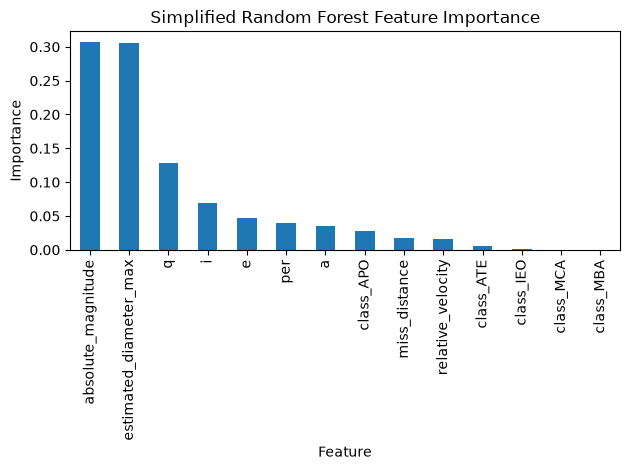

In [139]:
# Plot the Random Forest feature importance values so the strongest predictors are easier to interpret visually.
feature_importance.plot(
    kind="bar",
    x="Feature",
    y="Importance",
    legend=False
)

# Add clear chart labels and tighten the layout so feature names and axes are displayed neatly.
plt.title("Simplified Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### Feature importance

Absolute magnitude and estimated maximum diameter were the most influential features in the Simplified Random Forest. Perihelion distance was the next most important orbital feature.

These results support the exploratory analysis, which showed clear differences in brightness and estimated size between hazardous and non-hazardous records. Feature importance describes model use and does not demonstrate causation.

In [140]:
# Create confusion matrices for both final candidate models using the same test data.
logistic_matrix = confusion_matrix(y_test, logistic_predictions)

simplified_rf_matrix = confusion_matrix(
    y_test,
    simplified_rf_test_predictions
)

# Print the raw counts first so the classification errors can be compared directly.
print("Logistic Regression:")
print(logistic_matrix)

print("\nSimplified Random Forest:")
print(simplified_rf_matrix)

Logistic Regression:
[[31301  9389]
 [  844  6309]]

Simplified Random Forest:
[[33006  7684]
 [ 1017  6136]]


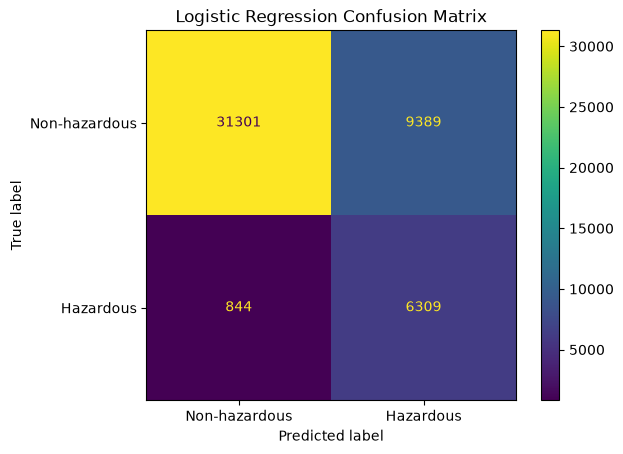

In [141]:
# Visualise the Logistic Regression confusion matrix with descriptive class labels.
# This makes the balance between correctly identified hazardous objects and false classifications easier to interpret.
ConfusionMatrixDisplay(
    confusion_matrix=logistic_matrix,
    display_labels=["Non-hazardous", "Hazardous"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

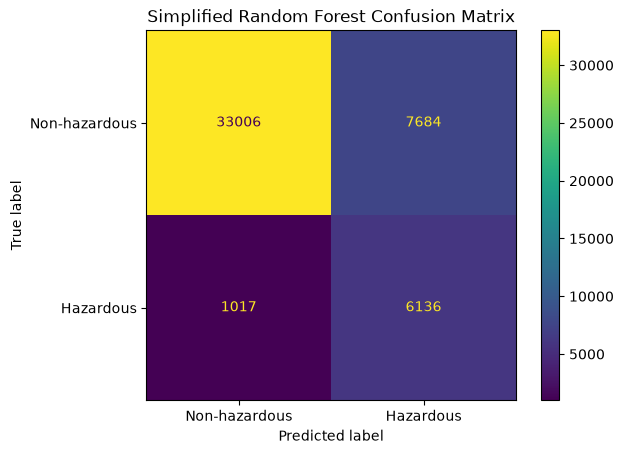

In [142]:
# Visualise the simplified Random Forest confusion matrix in the same format for a direct comparison.
ConfusionMatrixDisplay(
    confusion_matrix=simplified_rf_matrix,
    display_labels=["Non-hazardous", "Hazardous"]
).plot()

plt.title("Simplified Random Forest Confusion Matrix")
plt.show()

### Confusion matrix comparison

Logistic Regression identified 6,309 hazardous records and missed 844. The Simplified Random Forest identified 6,136 hazardous records and missed 1,017.

Logistic Regression therefore identified 173 more hazardous records. However, the Simplified Random Forest produced fewer false positives: 7,684 compared with 9,389.

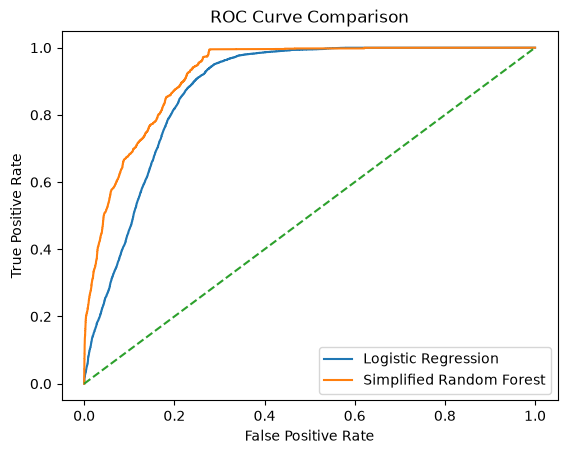

In [143]:
# Calculate the false-positive and true-positive rates across classification thresholds for both models.
# These values are used to build ROC curves and compare how well the models separate the two classes overall.
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

simplified_rf_fpr, simplified_rf_tpr, _ = roc_curve(
    y_test,
    simplified_rf_probabilities
)

# Plot both ROC curves on the same axes so their performance can be compared across thresholds.
plt.plot(
    logistic_fpr,
    logistic_tpr,
    label="Logistic Regression"
)

plt.plot(
    simplified_rf_fpr,
    simplified_rf_tpr,
    label="Simplified Random Forest"
)

# Add the diagonal reference line representing random classification performance.
plt.plot([0, 1], [0, 1], linestyle="--")

# Label the chart and display the legend for the two models.
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### ROC curve interpretation

Both models performed substantially better than random classification. The Simplified Random Forest achieved the higher ROC-AUC of 0.919, compared with 0.878 for Logistic Regression, indicating stronger overall class separation across different thresholds.

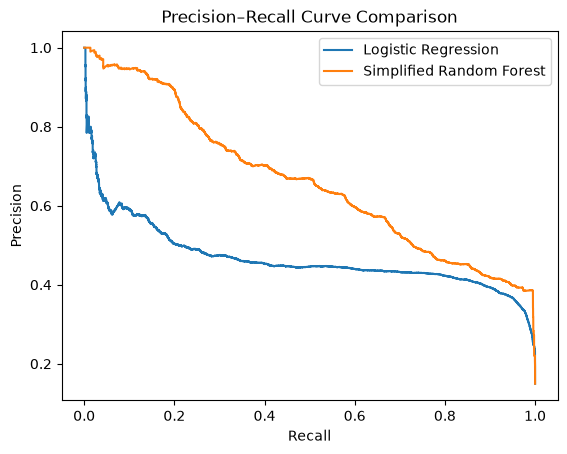

In [144]:
# Calculate precision and recall across different probability thresholds for both models.
# This is useful for the imbalanced target because it focuses directly on performance for the positive hazardous class.
logistic_precision, logistic_recall, _ = precision_recall_curve(
    y_test,
    logistic_probabilities
)

simplified_rf_precision, simplified_rf_recall, _ = precision_recall_curve(
    y_test,
    simplified_rf_probabilities
)

# Plot both precision-recall curves together to show the trade-off between identifying more hazardous records and producing false positives.
plt.plot(
    logistic_recall,
    logistic_precision,
    label="Logistic Regression"
)

plt.plot(
    simplified_rf_recall,
    simplified_rf_precision,
    label="Simplified Random Forest"
)

plt.title("Precision–Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

### Precision–recall interpretation

The Simplified Random Forest generally maintained higher precision across a range of recall values. Logistic Regression nevertheless achieved the highest recall at its selected classification setting, which supported its selection where false negatives were considered the greater risk.

## Exporting final model results

Export the final model evaluation outputs so they can be used directly in the Power BI dashboard.

In [145]:
# Recreate the final model-comparison table in a format that can be exported for the Power BI dashboard.
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy_score(y_test, logistic_predictions),
        precision_score(y_test, logistic_predictions),
        recall_score(y_test, logistic_predictions),
        f1_score(y_test, logistic_predictions),
        roc_auc_score(y_test, logistic_probabilities)
    ],
    "Simplified Random Forest": [
        accuracy_score(y_test, simplified_rf_test_predictions),
        precision_score(y_test, simplified_rf_test_predictions),
        recall_score(y_test, simplified_rf_test_predictions),
        f1_score(y_test, simplified_rf_test_predictions),
        roc_auc_score(y_test, simplified_rf_probabilities)
    ]
})

# Export the results without the pandas index so the CSV contains only the fields needed in Power BI.
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

# Display the rounded table as a final check of the exported model metrics.
model_comparison.round(3)

,Metric,Logistic Regression,Simplified Random Forest
0,Accuracy,0.786,0.818
1,Precision,0.402,0.444
2,Recall,0.882,0.858
3,F1-score,0.552,0.585
4,ROC-AUC,0.878,0.919


In [146]:
# Recreate the two final confusion matrices so their individual counts can be exported.
logistic_matrix = confusion_matrix(
    y_test,
    logistic_predictions
)

simplified_rf_matrix = confusion_matrix(
    y_test,
    simplified_rf_test_predictions
)

# Reshape the matrix values into a simple table with one row for each classification outcome.
# This format is much easier to use in Power BI than exporting the 2x2 matrices directly.
confusion_matrix_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Simplified Random Forest",
        "Simplified Random Forest",
        "Simplified Random Forest",
        "Simplified Random Forest"
    ],
    "Classification": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    "Count": [
        logistic_matrix[0, 0],
        logistic_matrix[0, 1],
        logistic_matrix[1, 0],
        logistic_matrix[1, 1],
        simplified_rf_matrix[0, 0],
        simplified_rf_matrix[0, 1],
        simplified_rf_matrix[1, 0],
        simplified_rf_matrix[1, 1]
    ]
})

# Save the confusion-matrix counts for use in the dashboard, again leaving out the pandas index.
confusion_matrix_results.to_csv(
    "confusion_matrix_results.csv",
    index=False
)

# Display the export table to check that each model has all four classification outcomes.
confusion_matrix_results

,Model,Classification,Count
0,Logistic Regression,True Negative,31301
1,Logistic Regression,False Positive,9389
2,Logistic Regression,False Negative,844
3,Logistic Regression,True Positive,6309
4,Simplified Random Forest,True Negative,33006
5,Simplified Random Forest,False Positive,7684
6,Simplified Random Forest,False Negative,1017
7,Simplified Random Forest,True Positive,6136


In [147]:
# Recreate the simplified Random Forest feature-importance table for export.
feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": simplified_random_forest.feature_importances_
})

# Keep the features ordered from most to least important for easier use in the dashboard.
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Export the feature importance results for the Power BI visual.
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

# Display the final table as a quick check of the exported values.
feature_importance

,Feature,Importance
0,absolute_magnitude,0.307517
1,estimated_diameter_max,0.305344
6,q,0.128685
7,i,0.068959
4,e,0.046357
8,per,0.039916
5,a,0.035178
9,class_APO,0.028009
3,miss_distance,0.017221
2,relative_velocity,0.015906


## Conclusion

Both models showed useful predictive performance on unseen asteroids. Logistic Regression achieved the highest recall at 0.882, compared with 0.858 for the Simplified Random Forest, and therefore missed fewer hazardous records.

The Simplified Random Forest achieved higher accuracy, precision, F1-score and ROC-AUC, offering a stronger overall balance between performance measures. However, because false negatives were considered the more serious error, Logistic Regression was selected as the preferred model for this project.

The Random Forest settings were adjusted after reviewing test-set performance. Future work should use a separate validation set or grouped cross-validation for model selection before completing one final test-set evaluation.

The findings apply to the matched subset containing supplementary orbital data and should not automatically be generalised to unmatched NEO records. 